#<b>Lamaah: A YOLO-Based Model for Multi-Scale Object Detection in UAV Systems</b>

---

**👨‍💻Team Members:**
*   Alanoud Abaalkhail - 443010774
*   Madawee Alabdulkreem - 443012689
*   Mounerh Alzamil - 443013529
*   Wajd Alomar - 443011050

**Supervisor** : Dr. Wojdan BinSaeedan



---


CS Department - Second semester 1447 H- 2026 G

# **Introduction**

Object detection in UAV imagery is challenging due to scale variation and complex backgrounds, especially for small objects.

To address this, we propose **Lamaah**, an enhanced YOLOv26-based model that improves detection using three main components: **SVA**, **PBAP-Net**, and **ACMF-Head**. These modules enhance feature extraction, multi-scale fusion, and feature consistency.

* Experimental results on VisDrone2019 show that Lamaah achieves **47% mAP@0.5**, outperforming the baseline by **7.5%**, while maintaining efficient computation (**105.8 GFLOPs**, **15.2M parameters**).


# **1- Environment Setup**


---



**Import Packages**

In [ ]:
# System & File Operations
import sys
import zipfile
from pathlib import Path
import shutil

# Image Processing
from PIL import Image
import cv2

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

# Plotting
import matplotlib.pyplot as plt

# Data Processing
import pandas as pd
import json

# Object Detection Libraries
import ultralytics
from ultralytics import YOLO
from ultralytics.nn.modules.conv import Conv

# COCO Evaluation Tools
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Utilities
import time

In [ ]:
print(sys.executable)

C:\Users\PCD\anaconda3\envs\gp_f9_env\python.exe


**GPU Cheack**

 Cheack GPU if it's available or not, if not Activative it

In [ ]:
!nvidia-smi

Sat May  2 17:31:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.79                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090      WDDM  |   00000000:01:00.0  On |                  Off |
|  0%   46C    P8             13W /  450W |    1023MiB /  24564MiB |     22%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu130
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4090


# **2- Dataset**


---




In this study, we use the **VisDrone2019 dataset**, a widely used benchmark for UAV object detection. It consists of real-world images collected from 14 cities in China, covering diverse urban and rural environments.

 * The dataset contains **10,209 images** divided into training (6,471), validation (548), and testing (1,610) sets.

 * It includes 10 object classes: pedestrian, people, bicycle, car, van, truck, tricycle, awning-tricycle, bus, and motor. Object sizes follow COCO-based categories (small, medium, and large). The dataset presents several challenges such as small objects, scale variation, occlusion, and dense scenes. All experiments are conducted using the official dataset split to ensure fair comparison.

Dataset link: [VisDrone2019 Dataset](https://github.com/VisDrone/VisDrone-Dataset)

In [ ]:
'''D:/F9_WM/
│
├── VisDrone2019-DET-train.zip
├── VisDrone2019-DET-val.zip
├── VisDrone2019-DET-test-dev.zip
│
├── VisDrone2019-DET-train/
├── VisDrone2019-DET-val/
├── VisDrone2019-DET-test-dev/

'''

# Set the root folder where the ZIP files are stored
zip_root = Path("D:/F9_WM")

# Set the output folder where the converted YOLO dataset will be saved
output_root = Path("D:/F9_WM/VisDrone2019-DET-YOLO")
output_root.mkdir(parents=True, exist_ok=True)

# Map each split name (train / val / test) to its corresponding ZIP filename
zips = {
    "train": "VisDrone2019-DET-train.zip",
    "val": "VisDrone2019-DET-val.zip",
    "test": "VisDrone2019-DET-test-dev.zip"
}

extract_paths = {}

# Loop over each split: verify the ZIP exists, then extract it to its folder
for split, zip_name in zips.items():
    zip_path = zip_root / zip_name
    extract_path = zip_root / zip_name.replace(".zip", "")
    extract_paths[split] = extract_path

    if not zip_path.exists():
        print(f" ZIP not found: {zip_path}")
        continue
    extract_path.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_path)

    print(f"Extracted {split} to {extract_path}")

Extracted train to D:\F9_WM\VisDrone2019-DET-train
Extracted val to D:\F9_WM\VisDrone2019-DET-val
Extracted test to D:\F9_WM\VisDrone2019-DET-test-dev


In [ ]:
# Print the first few files inside each extracted folder to confirm extraction succeeded
print("\n  After extraction:")
for split, zip_name in zips.items():
    folder = zip_root / zip_name.replace(".zip", "")
    if folder.exists():
        print(f"{split}:")
        print(list(folder.iterdir())[:5], "...")
    else:
        print(f"{split}: not found")

# **3- Data Exploration and Preprocessing**


---



### **3.1. Convert Visdrone Fromt to Yolo Format**




* The VisDrone dataset uses a bounding box annotation format that differs from the YOLO format. Therefore, a conversion step is required before training as shown in the Figure.


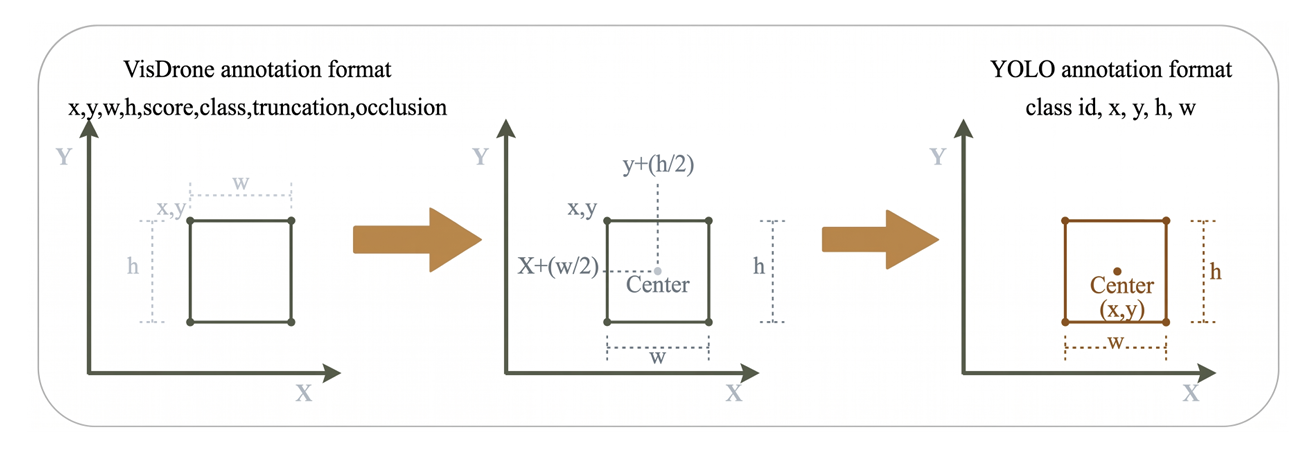

* All values are normalized between 0 and 1
* Ignores invalid annotations (score = 0)
* Converts class indices to 0-based indexing




In [ ]:
def visdrone2yolo(source_dir, split):
    images_dir = None
    ann_dir = None

    # Find the images and annotations
    for sub in source_dir.glob("**/images"):
        images_dir = sub
        ann_dir = sub.parent / "annotations"
        if images_dir.exists() and ann_dir.exists():
            break
    if images_dir is None or not ann_dir.exists():
        print(f" No images/annotations found in {source_dir}")
        return

    # Create output folders for YOLO images and labels
    images_out = output_root / "images" / split
    labels_out = output_root / "labels" / split
    images_out.mkdir(parents=True, exist_ok=True)
    labels_out.mkdir(parents=True, exist_ok=True)

    for img_file in images_dir.glob("*.jpg"):
        # Copy the image to the YOLO output folder
        shutil.copy2(img_file, images_out / img_file.name)

        ann_file = ann_dir / (img_file.stem + ".txt")
        if not ann_file.exists():
            continue
        # Get image dimensions for normalization
        img = Image.open(img_file)
        w, h = img.size
        dw, dh = 1.0 / w, 1.0 / h

        lines = []

        with open(ann_file, encoding="utf-8") as f:
            for row in f.read().strip().splitlines():
                parts = row.split(",")
                # Skip ignored regions (score == 0)
                if parts[4].strip() != "0":
                    x, y, bw, bh = map(float, parts[:4]) # Extract bounding box
                    cls = int(parts[5]) - 1       # class index (0-based)

                    # Convert to YOLO normalized center format
                    xc, yc = (x + bw/2)*dw, (y + bh/2)*dh
                    bw, bh = bw*dw, bh*dh
                    lines.append(f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

        if lines:
            (labels_out / ann_file.name).write_text("\n".join(lines), encoding="utf-8")

# Run the conversion for all three splits
for split, folder in extract_paths.items():
    visdrone2yolo(folder, split)

### **3.2. YAML config file**


---


A YAML file is used in YOLO to define where the dataset is located and what classes are included.

* it contains: Dataset path, Training and validation folders, Number and names of classes.


In [ ]:
# Create YAML file for YOLO dataset configuration
dataset_yaml_content = f"""
path: {output_root}
train: images/train
val: images/val
nc: 10
names: ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']
"""

dataset_yaml_path = output_root / "visdrone.yaml"
dataset_yaml_path.write_text(dataset_yaml_content.strip(), encoding="utf-8")

print(f"[INFO] Dataset YAML created: {dataset_yaml_path}")

[INFO] Dataset YAML created: D:\F9_WM\VisDrone2019-DET-YOLO\visdrone.yaml


In [ ]:
# Count and verify the number of images and label files for each split

for split in ["train", "val", "test"]:
    n_imgs = len(list(Path(output_root / "images" / split).glob("*.jpg")))
    n_lbls = len(list(Path(output_root / "labels" / split).glob("*.txt")))
    print(f"{split}: {n_imgs} images, {n_lbls} labels")

train: 6471 images, 6471 labels
val: 548 images, 548 labels
test: 1611 images, 1610 labels


After preparing the dataset, it is important to verify that the conversion process was successful and that images and labels are correctly aligned.



### **3.3. Dataset Visualization**

**Training Set Samples**

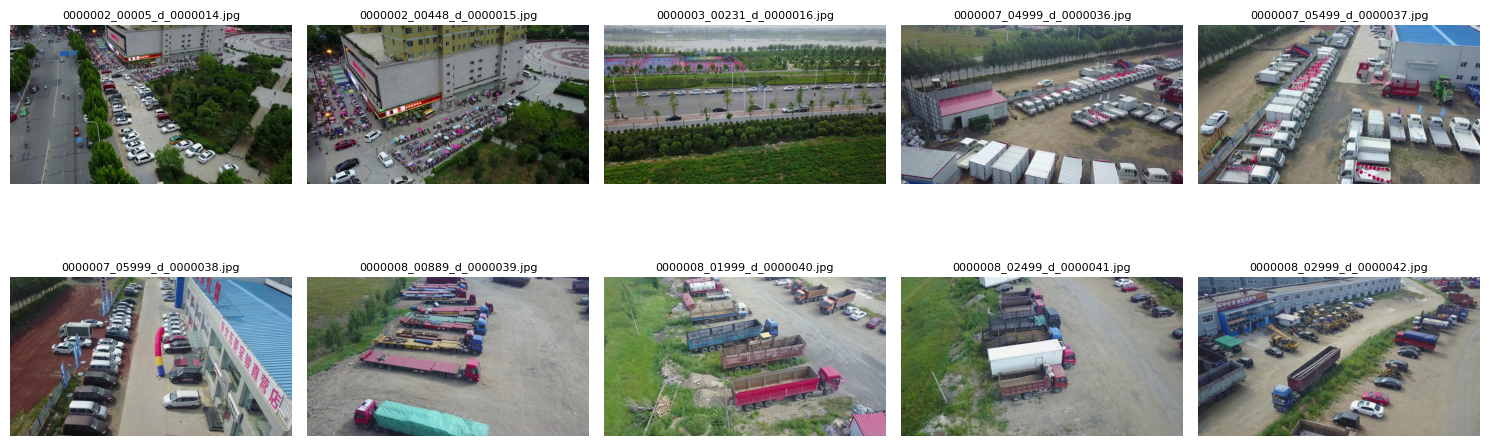

In [ ]:
images_path = output_root / "images" / "train"
image_files = list(images_path.glob("*.jpg"))[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    if i < len(image_files):
        img = Image.open(image_files[i])
        ax.imshow(img)
        ax.set_title(image_files[i].name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Validation Set Samples**

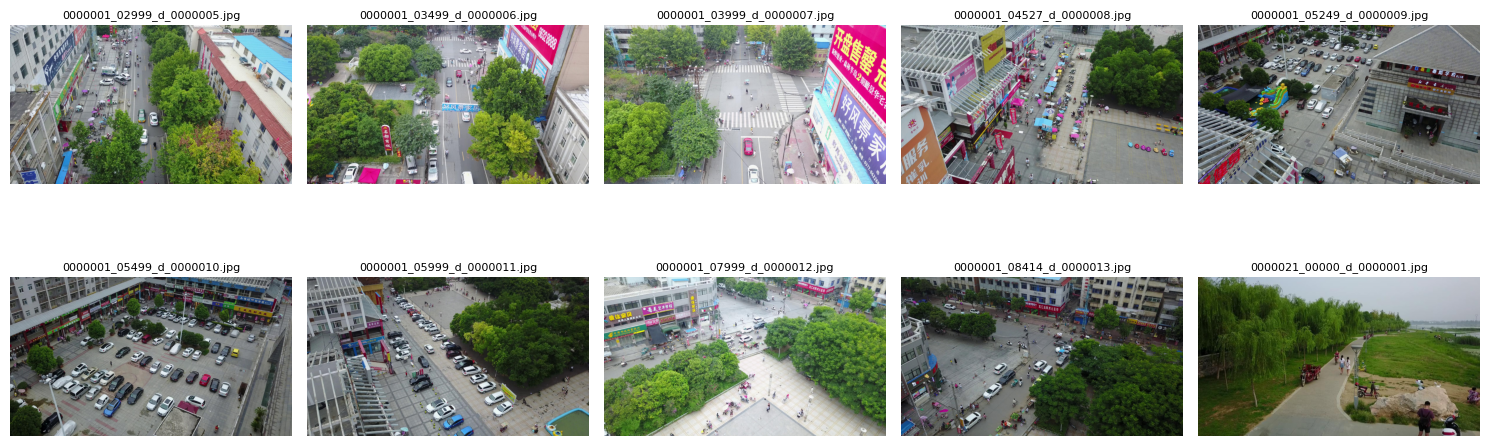

In [ ]:
images_path = output_root / "images" / "val"
image_files = list(images_path.glob("*.jpg"))[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    if i < len(image_files):
        img = Image.open(image_files[i])
        ax.imshow(img)
        ax.set_title(image_files[i].name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Test Set Samples**

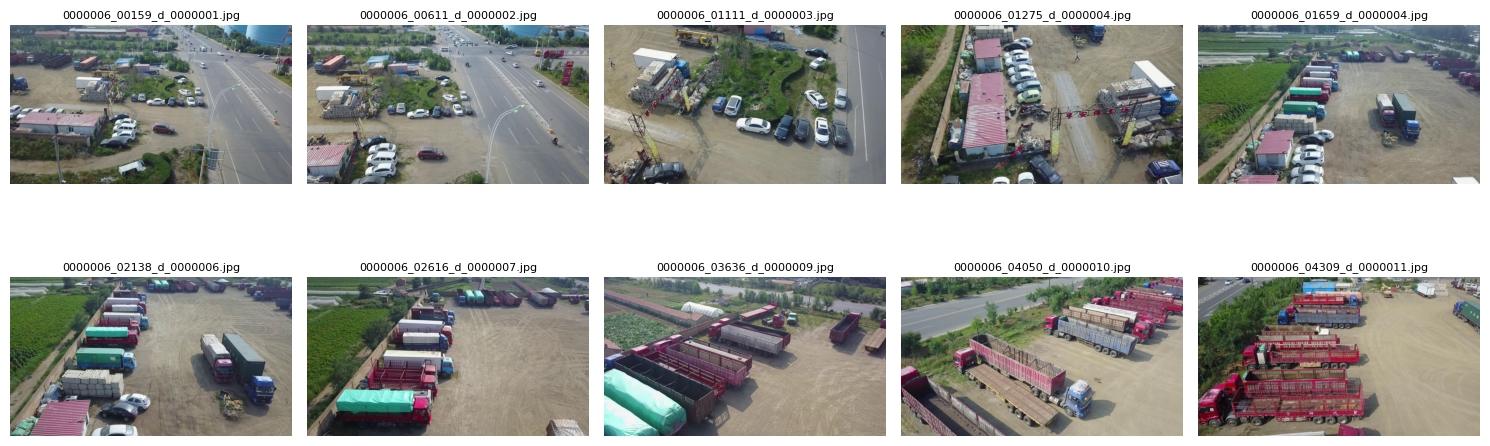

In [ ]:
images_path = output_root / "images" / "test"
image_files = list(images_path.glob("*.jpg"))[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    if i < len(image_files):
        img = Image.open(image_files[i])
        ax.imshow(img)
        ax.set_title(image_files[i].name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

# **4- Model Architecture**

---

* Custom modules (SVA, PBAP-Net, and ACMF-head) were integrated by modifying the Ultralytics source code.

* The implementations were added in **block.py**, exposed in **__init__.py**, and registered in **tasks.py** to enable proper integration within the model architecture.


## **4.1. Baseline model**

In this study we used **YOLOv26** as the baseline

**YOLOv26 introduces several improvements, including:**
* Removing DFL for simpler deployment
* Enabling a fully end-to-end design without NMS to reduce latency, and incorporating ProgLoss
* STAL to improve small-object detection.
* MuSGD optimizer to enhance training stability and convergence.

YOLOv26 is lightweight, fast, and optimized for real-time detection with improved small-object performance.


**Baseline YAML file**

In [ ]:
YAML_CONTENT = """
# Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# Ultralytics YOLO26 object detection model with P3/8 - P5/32 outputs
# Model docs: https://docs.ultralytics.com/models/yolo26
# Task docs: https://docs.ultralytics.com/tasks/detect

# Parameters
nc: 80 # number of classes
end2end: True # whether to use end-to-end mode
reg_max: 1 # DFL bins
scales: # model compound scaling constants, i.e. 'model=yolo26n.yaml' will call yolo26.yaml with scale 'n'
  # [depth, width, max_channels]
  n: [0.50, 0.25, 1024] # summary: 260 layers, 2,572,280 parameters, 2,572,280 gradients, 6.1 GFLOPs
  s: [0.50, 0.50, 1024] # summary: 260 layers, 10,009,784 parameters, 10,009,784 gradients, 22.8 GFLOPs
  m: [0.50, 1.00, 512] # summary: 280 layers, 21,896,248 parameters, 21,896,248 gradients, 75.4 GFLOPs
  l: [1.00, 1.00, 512] # summary: 392 layers, 26,299,704 parameters, 26,299,704 gradients, 93.8 GFLOPs
  x: [1.00, 1.50, 512] # summary: 392 layers, 58,993,368 parameters, 58,993,368 gradients, 209.5 GFLOPs

# YOLO26n backbone
backbone:
  # [from, repeats, module, args]
  - [-1, 1, Conv, [64, 3, 2]] # 0-P1/2
  - [-1, 1, Conv, [128, 3, 2]] # 1-P2/4
  - [-1, 2, C3k2, [256, False, 0.25]]
  - [-1, 1, Conv, [256, 3, 2]] # 3-P3/8
  - [-1, 2, C3k2, [512, False, 0.25]]
  - [-1, 1, Conv, [512, 3, 2]] # 5-P4/16
  - [-1, 2, C3k2, [512, True]]
  - [-1, 1, Conv, [1024, 3, 2]] # 7-P5/32
  - [-1, 2, C3k2, [1024, True]]
  - [-1, 1, SPPF, [1024, 5, 3, True]] # 9
  - [-1, 2, C2PSA, [1024]] # 10

# YOLO26n head
head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]] # cat backbone P4
  - [-1, 2, C3k2, [512, True]] # 13

  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]] # cat backbone P3
  - [-1, 2, C3k2, [256, True]] # 16 (P3/8-small)

  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 13], 1, Concat, [1]] # cat head P4
  - [-1, 2, C3k2, [512, True]] # 19 (P4/16-medium)

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 10], 1, Concat, [1]] # cat head P5
  - [-1, 1, C3k2, [1024, True, 0.5, True]] # 22 (P5/32-large)

  - [[16, 19, 22], 1, Detect, [nc]] # Detect(P3, P4, P5)

"""

YAML_PATH = "yolo26s.yaml"

with open(YAML_PATH, "w", encoding="utf-8") as f:
    f.write(YAML_CONTENT)

In [ ]:
model = YOLO("yolo26s.yaml")
model.info()

YOLO26s summary: 260 layers, 10,009,784 parameters, 10,009,784 gradients, 22.8 GFLOPs


(260, 10009784, 10009784, 22.838476800000002)

In [ ]:
for i, layer in enumerate(model.model.model):
    print(f"{i}: {layer.__class__.__name__}")

0: Conv
1: Conv
2: C3k2
3: Conv
4: C3k2
5: Conv
6: C3k2
7: Conv
8: C3k2
9: SPPF
10: C2PSA
11: Upsample
12: Concat
13: C3k2
14: Upsample
15: Concat
16: C3k2
17: Conv
18: Concat
19: C3k2
20: Conv
21: Concat
22: C3k2
23: Detect


## **4.2. Lamaah model**
This section presents the proposed method and its implementation. Detecting small UAV objects is challenging due to scale variation, loss of fine details, and weak multi-scale fusion. To address this, we propose **Lamaah**, a modified YOLOv26s model with three components: **SVA**, **PBAP-Net**, and **ACMF-Head**, which are described in the following subsections.

---
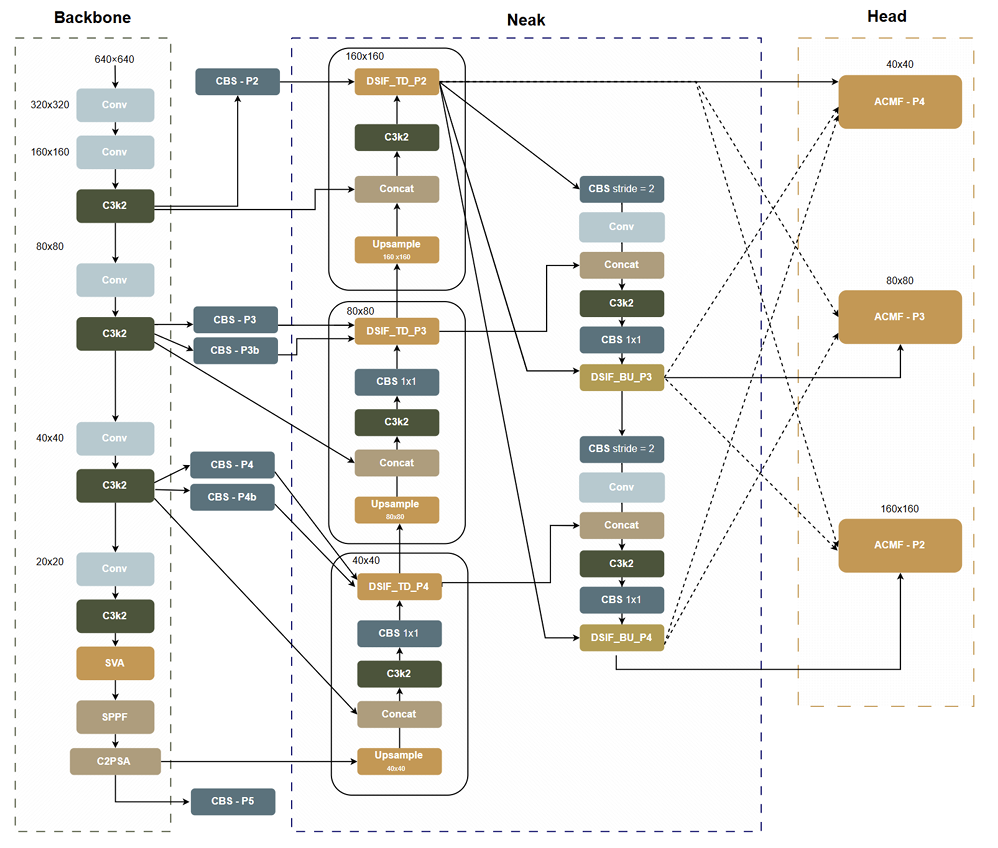


### **4.2.2. Sparse Vision Attention (SVA)**

SVA module designed to improve feature representation by combining two parallel branches:

* **Branch 1:** Learns channel importance (attention weights)
* **Branch 2:** Sparse multi-head self-attention (long-range spatial modeling)
It is used to enhance the model ability to focus on important regions while reducing computational cost.

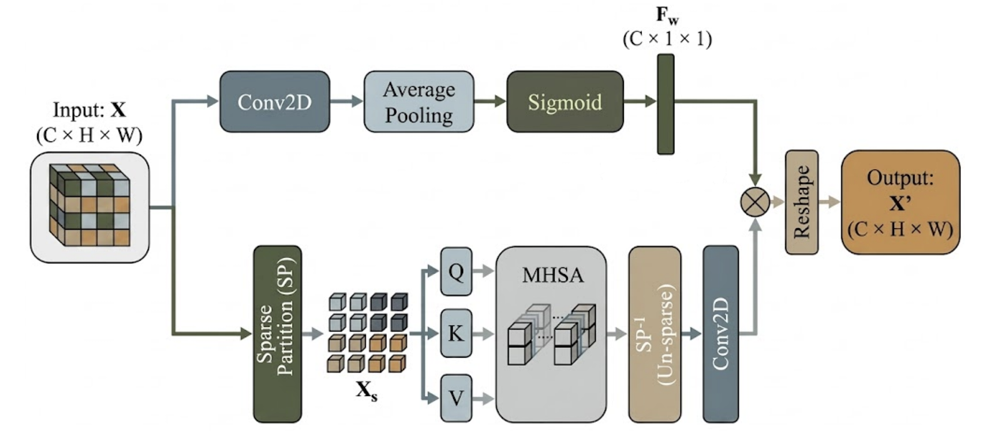

In [ ]:
%%writefile C:/Users/PCD/anaconda3/envs/gp_f9_env/Lib/site-packages/ultralytics/nn/modules/sva_yolo26.py

# Multi-head self-attention applied across the channel dimension
'''Standard MHSA applied on flattened image tokens.
   It computes relationships between all spatial positions using: Q (Query), K (Key), V (Value)'''

class MHSA(nn.Module):

    def __init__(self, c: int, num_heads: int = 8):
        super().__init__()
        # Ensure channel count is divisible by number of heads
        assert c % num_heads == 0, (f"channels {c} must be divisible by num_heads {num_heads}")

        self.nh = num_heads
        self.hd = c // num_heads       # head dimension
        self.sc = self.hd ** -0.5      # 1/√(head_dim) scale

        # Linear projections for Query, Key, Value
        self.q = nn.Linear(c, c, bias=False)
        self.k = nn.Linear(c, c, bias=False)
        self.v = nn.Linear(c, c, bias=False)

        # Final output projection after merging heads
        self.proj = nn.Linear(c, c, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape

        # Convert feature map to sequence (tokens)
        tokens = x.flatten(2).transpose(1, 2)

        # Compute Q, K, V
        q = self.q(tokens)
        k = self.k(tokens)
        v = self.v(tokens)

        # Multi-head split
        def _heads(t: torch.Tensor) -> torch.Tensor:
            return t.reshape(B, -1, self.nh, self.hd).transpose(1, 2)

        q, k, v = _heads(q), _heads(k), _heads(v)

         # Attention scores (similarity between Q and K)
        attn = (q @ k.transpose(-2, -1)) * self.sc
        attn = attn.softmax(dim=-1)
        # Weighted aggregation of values
        out  = attn @ v

        # Merge attention heads back
        out = out.transpose(1, 2).reshape(B, -1, C)

        out = self.proj(out)                             # (B, H·W, C)

        # Restore feature map shape (B, H·W, C) → (B, C, H, W)
        return out.transpose(1, 2).reshape(B, C, H, W)


# SVA: Sparse Vision Attention - Fuses Channel Attention (Branch 1) with Sparse MHSA (Branch 2)
class sva(nn.Module):
    def __init__(self, c: int, S: int = 2, num_heads: int = 8):
        super().__init__()
        assert c % num_heads == 0, (f"channels {c} must be divisible by num_heads {num_heads}")
        # sparsity stride: every S pixels in each direction forms one block
        self.S = S

         # Branch 1: Conv → channel attention weights
        self.b1 = nn.Conv2d(c, c, kernel_size=1, bias=False)

        # Branch 2: sparse attention using MHSA
        self.ca = MHSA(c, num_heads)

        # Conv after unsparse
        self.b2 = nn.Conv2d(c, c, kernel_size=1, bias=False)

       # Sparse partitioning: splits feature map into interleaved SxS blocks
    def _sp(self, x: torch.Tensor, S: int) -> torch.Tensor:
        B, C, H, W = x.shape
        return (
            x.reshape(B, C, H // S, S, W // S, S)
             .permute(0, 3, 5, 1, 2, 4)
             .contiguous()
             .reshape(B * S * S, C, H // S, W // S)
        )

    # Unsparse: restores original spatial structure after attention processing
    def _unsp(self, x: torch.Tensor, B: int, H: int, W: int, S: int) -> torch.Tensor:
        C = x.shape[1]
        return (
            x.reshape(B, S, S, C, H // S, W // S)
             .permute(0, 3, 4, 1, 5, 2)
             .contiguous()
             .reshape(B, C, H, W)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        S = self.S

        # S=1 (no sparsification) if spatial size is not divisible
        if H % S != 0 or W % S != 0:
            S = 1

        # Branch 1 - Computes global channel importance weights:
        F_w = torch.sigmoid(F.adaptive_avg_pool2d(self.b1(x), output_size=1))

        # Branch 2 - Sparse attention :
        xs  = self._sp(x, S)
        F_p = self.b2(self._unsp(self.ca(xs), B, H, W, S))     # attention → unsparse → conv

        # Final fusion : combine channel attention + spatial attention
        return F_w * F_p

### **4.2.2. Progressive Bidirectional Auxiliary Pyramid Network (PBAP-Net)**
PBAP-Net is designed to enhance multi-scale feature representation by enabling effective information flow across different pyramid levels. It adopts a bidirectional structure that combines top-down semantic information with bottom-up spatial details, improving the model’s ability to detect objects of varying sizes, especially small and complex targets in UAV imagery.

To achieve this, a **Sparse Dense Fusion (DSIF)** mechanism is introduced to aggregate features from multiple scales into a unified representation.

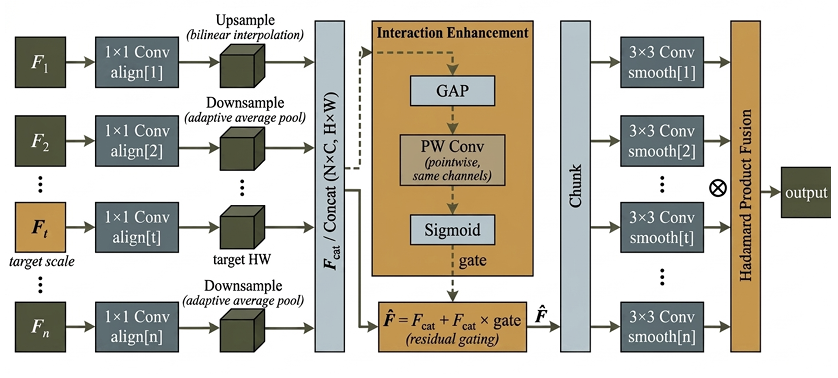


In [ ]:
%%writefile C:/Users/PCD/anaconda3/envs/gp_f9_env/Lib/site-packages/ultralytics/nn/modules/pbap_yolo26.py
# PBAP: Bidirectional multi-scale feature aggregation module

# Uses DSIF Level to fuse features from different pyramid levels (top-down + bottom-up)
# Add Five head classes handle the two directions and three output scales.

class dsifLevel(nn.Module):

    def __init__(self, in_channels, out_channels, target_idx):
        super().__init__()
        self.n = len(in_channels)
        self.target_idx = target_idx

         # Align all inputs to same number of channels
        self.align = nn.ModuleList([
            Conv(int(c), out_channels, 1, 1) for c in in_channels
        ])

        fused_c = out_channels * self.n
        # Generate attention weights for fused features
        self.pw = nn.Conv2d(fused_c, fused_c, 1, 1)
        # Smooth each feature after splitting
        self.smooth = nn.ModuleList([
            Conv(out_channels, out_channels, 3, 1) for _ in range(self.n)
        ])

        self.c2 = out_channels

    def forward(self, feats):
        # Get target spatial size
        target_hw = feats[self.target_idx].shape[-2:]
        resized = []

        # Resize all features to same resolution
        for j, x in enumerate(feats):
            x = self.align[j](x)
            if j < self.target_idx:
                x = F.adaptive_avg_pool2d(x, target_hw)          # downsample
            elif j > self.target_idx:
                x = F.interpolate(x, size=target_hw, mode="bilinear", align_corners=False)  # upsample
            resized.append(x)

        # Concatenate and apply attention
        F_cat = torch.cat(resized, dim=1)
        gate  = torch.sigmoid(self.pw(F.adaptive_avg_pool2d(F_cat, 1)))
        F_hat = F_cat + F_cat * gate

        # Split features and refine
        splits  = torch.chunk(F_hat, self.n, dim=1)
        smoothed = [self.smooth[i](splits[i]) for i in range(self.n)]

        # Multiply features to enhance important information
        out = smoothed[0]
        for i in range(1, self.n):
            out = out * smoothed[i]

        return out


# Top-down path: fuses information from P2, P3, P4, P5 → output at P4 scale (high → low level features)
class pbap_TD_P4(nn.Module):
    def __init__(self, c1, out_c):
        super().__init__()
        self.dsif = dsifLevel(c1, out_c, target_idx=2)
        self.c2 = out_c

    def forward(self, x):
        return self.dsif(x)


# Top-down path: output at P3 scale
class pbap_TD_P3(nn.Module):
    def __init__(self, c1, out_c):
        super().__init__()
        self.dsif = dsifLevel(c1, out_c, target_idx=1)
        self.c2 = out_c

    def forward(self, x):
        return self.dsif(x)


# Top-down path: output at P2 scale
class pbap_TD_P2(nn.Module):
    def __init__(self, c1, out_c):
        super().__init__()
        self.dsif = dsifLevel(c1, out_c, target_idx=0)
        self.c2 = out_c

    def forward(self, x):
        return self.dsif(x)


# Bottom-up path: output at P3 scale (low → high level features)
class pbap_BU_P3(nn.Module):
    def __init__(self, c1, out_c):
        super().__init__()
        self.dsif = dsifLevel(c1, out_c, target_idx=1)
        self.c2 = out_c

    def forward(self, x):
        return self.dsif(x)


# Bottom-up path: output at P4 scale (coarsest)
class pbap_BU_P4(nn.Module):
    def __init__(self, c1, out_c):
        super().__init__()
        self.dsif = dsifLevel(c1, out_c, target_idx=2)
        self.c2 = out_c

    def forward(self, x):
        return self.dsif(x)

In [ ]:
# Import all pbap classes and verify they load without errors
from ultralytics.nn.modules import DSIFLevel, pbap_TD_P4, pbap_TD_P3, pbap_TD_P2, pbap_BU_P3, pbap_BU_P4

print("pbap modules loaded successfully")

In [ ]:
# Register pbap in ultralytics __init__.py

ultra_path = Path(ultralytics.__file__).parent
modules_path = ultra_path / "nn" / "modules" / "__init__.py"

text = modules_path.read_text()

if "pbap_yolo26" not in text:
    text += "\nfrom .pbap_yolo26 import DSIFLevel, pbap_TD_P4, pbap_TD_P3, pbap_TD_P2, pbap_BU_P3, pbap_BU_P4\n"
    modules_path.write_text(text)

print("pbap registered")

### **4.2.3. Adaptive Channel Multi-Scale Fusion Head (ACMF-Head)**

ACMF-Head designed to enhance feature fusion across multiple scales by combining both scale-level importance and channel-wise attention. It adaptively weights features from different pyramid levels, allowing the model to better capture semantic relationships and spatial details. This improves detection robustness, especially in complex scenes with large scale variations.

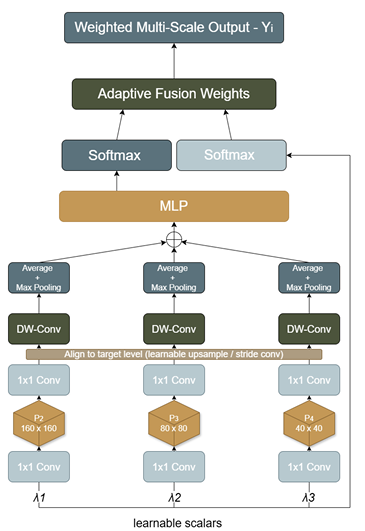

In [ ]:
%%writefile C:/Users/PCD/anaconda3/envs/gp_f9_env/Lib/site-packages/ultralytics/nn/modules/acmft3_yolo26.py

# ChannelMLP: generates channel-wise attention weights
# Takes a pooled feature vector and learns the importance of each channel
class ChannelMLP(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        h = max(channels // 4, 1)
        self.net = nn.Sequential(
            nn.Linear(channels, h),
            nn.ReLU(inplace=True),
            nn.Linear(h, channels),
        )

    def forward(self, x):
        return self.net(x.flatten(1))

# LearnableUpsample2x: replaces fixed upsampling with trainable upsampling
class LearnableUpsample2x(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.deconv = nn.ConvTranspose2d(
            channels, channels, kernel_size=4, stride=2, padding=1, bias=False
        )

    def forward(self, x):
        return self.deconv(x)

 # Core fusion block: combines:
  # 1) Scale attention (λ) → importance of each feature level (P2, P3, P4)
  # 2) Channel attention → importance of each channel within each feature map
class acmfLevel(nn.Module):
    def __init__(self, channels: int, target_idx: int = 0):
        super().__init__()
        C = int(channels)

        # Learnable weights for each feature level
        init = torch.zeros(3)
        init[target_idx] = 1.0
        self.lambdas = nn.Parameter(init)

        # Channel attention module
        self.mlp = ChannelMLP(C)

        # Depthwise convolution per level to enhance spatial information
        self.dw = nn.ModuleList([
            nn.Conv2d(C, C, kernel_size=3, padding=1, groups=C, bias=False)
            for _ in range(3)
        ])

        # Shared weights between channel and scale attention
        self.w1 = nn.Parameter(torch.tensor(0.5))
        self.w2 = nn.Parameter(torch.tensor(0.5))

    def forward(self, feats):
        B, C, _, _ = feats[0].shape

        # Scale attention: determines importance of each level
        s = F.softmax(self.lambdas, dim=0)

        # Compute channel attention for each level
        ch_attn = []
        for feat, dw in zip(feats, self.dw):
            f = dw(feat)

            # Combine max pooling and average pooling for richer representation
            pool = F.adaptive_max_pool2d(f, 1) + F.adaptive_avg_pool2d(f, 1)

            # MLP produces channel-wise weights
            ch_attn.append(self.mlp(pool))

        cw = F.softmax(torch.stack(ch_attn, dim=1), dim=1)  # Normalize attention across levels

        # Fuse features from all level - Each feature is weighted by both channel and scale attention
        out = sum(
            (self.w1 * cw[:, i, :].view(B, C, 1, 1) + self.w2 * s[i]) * feats[i]
            for i in range(3)
        )

        return out

# Base class: projects each input to a common channel count, aligns spatial
class _acmfBase(nn.Module):

    def __init__(self, c1, target_idx: int = 0, *args):
        super().__init__()

        # Extract channels for each input level
        chs = list(c1) if isinstance(c1, (list, tuple)) else [int(c1), int(args[0]), int(args[1])]
        C = chs[target_idx]
        self.c2 = C

        # Project all feature maps to the same channel dimension
        self.proj = nn.ModuleList([
            nn.Conv2d(c, C, kernel_size=1, bias=False) for c in chs
        ])

        # Align spatial sizes (downsample or upsample)
        align_configs = {
            0: [nn.Identity(),
                LearnableUpsample2x(C),
                nn.Sequential(LearnableUpsample2x(C), LearnableUpsample2x(C))],
            1: [nn.Conv2d(C, C, 3, stride=2, padding=1, bias=False),
                nn.Identity(),
                LearnableUpsample2x(C)],
            2: [nn.Sequential(nn.Conv2d(C, C, 3, stride=2, padding=1, bias=False),
                               nn.Conv2d(C, C, 3, stride=2, padding=1, bias=False)),
                nn.Conv2d(C, C, 3, stride=2, padding=1, bias=False),
                nn.Identity()],
        }

        self.align = nn.ModuleList(align_configs[target_idx])
        # Final fusion module
        self.fusion = acmfLevel(C, target_idx)

    def forward(self, x):
        projected = [p(f) for p, f in zip(self.proj, x)]
        aligned   = [a(f) for a, f in zip(self.align, projected)]
        return self.fusion(aligned)


# Three output heads — each fuses P2+P3+P4 but outputs at the target scale
class acmf_TD_P2(_acmfBase):
    # Output at P2 resolution (Small scale, 160×160)
    def __init__(self, c1, *args): super().__init__(c1, 0, *args)

class acmf_TD_P3(_acmfBase):
    # Output at P3 resolution (Medium scale, 80×80)
    def __init__(self, c1, *args): super().__init__(c1, 1, *args)

class acmf_TD_P4(_acmfBase):
    # Output at P4 resolution (Large scale, 40×40)
    def __init__(self, c1, *args): super().__init__(c1, 2, *args)

In [ ]:
# Import all acmf classes and verify they load without errors
from ultralytics.nn.modules.acmft3_yolo26 import acmf_TD_P2, acmf_TD_P3, acmf_TD_P4
print("acmf modules loaded successfully")

In [ ]:
# Register the acmf module in ultralytics __init__.py

ultra_path   = Path(ultralytics.__file__).parent
modules_path = ultra_path / "nn" / "modules" / "__init__.py"
text         = modules_path.read_text()

if "acmft3_yolo26" not in text:
    text += "\nfrom .acmft3_yolo26 import acmf_TD_P2, acmf_TD_P3, acmf_TD_P4\n"
    modules_path.write_text(text)
    print("acmf registered in __init__.py")
else:
    print("acmf already registered")

### **4.2.4. Lamaah YAML file**

Defines the full architecture of the proposed Lamaah model, which is built upon YOLOv26s with additional modules: SVA, PBAP-Net, and ACMF-Head.
<br><br>

**Architecture Description**

* **Backbone:**

Extracts hierarchical features using convolutional layers and C3k2 blocks.
The SVA module is applied at deeper layers to enhance global feature representation, followed by SPPF and C2PSA for multi-scale context and attention.

* **Neck (PBAP-Net):**

Performs bidirectional feature fusion:
Top-down path: propagates semantic information from deep layers (P5 → P2)
Bottom-up path: refines features by re-aggregating low-level details (P2 → P4)
This improves feature consistency across scales.

* **Head (ACMF):**

Applies adaptive cross-scale fusion to combine features from P2, P3, and P4, generating more informative representations for detection.
Detection Layer:
Final predictions are produced at three scales (P2, P3, P4) for improved small-object detection.

In [ ]:
%%writefile C:/Users/PCD/anaconda3/envs/gp_f9_env/Lib/site-packages/ultralytics/Lamaah.yaml

nc: 10
end2end: True
reg_max: 1

scales:
  # [depth_multiple, width_multiple, max_channels]
  s: [0.50, 0.50, 1024]

backbone:
  # [from, repeats, module, args]
  - [-1, 1, Conv, [64, 3, 2]]               # 0  P1 320x320
  - [-1, 1, Conv, [128, 3, 2]]              # 1  P2 160x160
  - [-1, 2, C3k2, [256, False, 0.25]]       # 2  backbone P2
  - [-1, 1, Conv, [256, 3, 2]]              # 3  P3 80x80
  - [-1, 2, C3k2, [512, False, 0.25]]       # 4  backbone P3
  - [-1, 1, Conv, [512, 3, 2]]              # 5  P4 40x40
  - [-1, 2, C3k2, [512, True]]              # 6  backbone P4
  - [-1, 1, Conv, [1024, 3, 2]]             # 7  P5 20x20
  - [-1, 2, C3k2, [1024, True]]             # 8
  - [-1, 1, sva, [2, 8]]                    # 9  SVA
  - [-1, 1, SPPF, [1024, 5, 3, True]]       # 10 spatial pyramid pooling
  - [-1, 2, C2PSA, [1024]]                  # 11 cross-stage partial with attention

head:
  # Six 1x1 CBS projections — tap backbone features for pbap input
  - [2,  1, Conv, [128, 1, 1]]              # 12  CBS-P2  160x160
  - [4,  1, Conv, [128, 1, 1]]              # 13  CBS-P3   80x80
  - [6,  1, Conv, [128, 1, 1]]              # 14  CBS-P4   40x40
  - [11, 1, Conv, [128, 1, 1]]              # 15  CBS-P5   20x20  (deep semantic anchor)
  - [4,  1, Conv, [128, 1, 1]]              # 16  CBS-P3 second tap (80x80)
  - [6,  1, Conv, [128, 1, 1]]              # 17  CBS-P4 second tap (40x40)

  # pbap top-down path: P5→P4→P3→P2
  - [11, 1, nn.Upsample, [None, 2, 'nearest']]  # 18  upsample P5
  - [[18, 6], 1, Concat, [1]]                   # 19  concat with P4
  - [-1, 2, C3k2, [512, True]]                  # 20
  - [-1, 1, Conv, [128, 1, 1]]                  # 21
  - [[14, 17, 21, 15], 1, pbap_TD_P4, [128]]    # 22  fused P4 output

  - [22, 1, nn.Upsample, [None, 2, 'nearest']]  # 23  upsample P4
  - [[23, 4], 1, Concat, [1]]                   # 24  concat with P3
  - [-1, 2, C3k2, [256, True]]                  # 25
  - [-1, 1, Conv, [128, 1, 1]]                  # 26
  - [[13, 16, 26, 15], 1, pbap_TD_P3, [128]]    # 27  fused P3 output

  - [27, 1, nn.Upsample, [None, 2, 'nearest']]  # 28  upsample P3
  - [[28, 2], 1, Concat, [1]]                   # 29  concat with P2
  - [-1, 2, C3k2, [256, False, 0.25]]           # 30
  - [[12, 30, 27, 15], 1, pbap_TD_P2, [128]]    # 31  fused P2 output

  # pbap bottom-up path: P2→P3→P4
  - [31, 1, Conv, [128, 3, 2]]                  # 32  downsample P2
  - [[32, 27], 1, Concat, [1]]                  # 33
  - [-1, 2, C3k2, [256, True]]                  # 34
  - [-1, 1, Conv, [128, 1, 1]]                  # 35
  - [[31, 35, 22, 15], 1, pbap_BU_P3, [128]]    # 36  refined P3

  - [36, 1, Conv, [128, 3, 2]]                  # 37  downsample P3
  - [[37, 22], 1, Concat, [1]]                  # 38
  - [-1, 2, C3k2, [512, True]]                  # 39
  - [-1, 1, Conv, [128, 1, 1]]                  # 40
  - [[31, 36, 40, 15], 1, pbap_BU_P4, [128]]    # 41  refined P4

  # acmf: adaptively fuse P2, P3, P4 outputs at each target scale
  - [[31, 36, 41], 1, acmf_TD_P2, []]           # 42  final P2 feature
  - [[31, 36, 41], 1, acmf_TD_P3, []]           # 43  final P3 feature
  - [[31, 36, 41], 1, acmf_TD_P4, []]           # 44  final P4 feature

  # Detection head takes all three scales and predicts bounding boxes
  - [[42, 43, 44], 1, Detect, [nc]]             # 45  output detections

**Check FLOPs to ensure the forward pass works**

In [ ]:
model = YOLO("Lamaah.yaml")
model.info()

YOLO26s_bima_csfa_nssa summary: 413 layers, 15,189,091 parameters, 15,189,091 gradients, 105.8 GFLOPs


(413, 15189091, 15189091, 105.77879039999999)

In [ ]:
for i, layer in enumerate(Lamaah.model.model):
    print(f"{i}: {layer.__class__.__name__}")

0: Conv
1: Conv
2: C3k2
3: Conv
4: C3k2
5: Conv
6: C3k2
7: Conv
8: C3k2
9: NSSA
10: SPPF
11: C2PSA
12: Conv
13: Conv
14: Conv
15: Conv
16: Conv
17: Conv
18: Upsample
19: Concat
20: C3k2
21: Conv
22: BIMA_TD_P4
23: Upsample
24: Concat
25: C3k2
26: Conv
27: BIMA_TD_P3
28: Upsample
29: Concat
30: C3k2
31: BIMA_TD_P2
32: Conv
33: Concat
34: C3k2
35: Conv
36: BIMA_BU_P3
37: Conv
38: Concat
39: C3k2
40: Conv
41: BIMA_BU_P4
42: CSFA_TD_P2
43: CSFA_TD_P3
44: CSFA_TD_P4
45: Detect


# **5. Training**

---

Both models were trained under identical settings to ensure a fair comparison.

 * The models were trained for 200 epochs with a batch size of 8 and an initial learning rate of 0.01.

 * The input resolution was set to 640×640 to balance accuracy and computational efficiency.

* Weight decay (0.0005) and momentum (0.937) were applied to improve generalization and convergence.

* The MuSGD optimizer was used to provide more stable and efficient training compared to standard SGD.

Additionally, **ablation studies** were performed to evaluate the contribution of each module. All experiments were conducted under the same environment and hyperparameters to ensure fairness and reproducibility.


### **5.1. Hyperparameters**

In [ ]:
# Define all training hyperparameters
epochs = 200
batch = 8
learning_rate = 0.01
momentum = 0.937
weight_decay = 0.0005
img_size = 640

## **5.2. Baseline**



In [ ]:
# Load the model
model = YOLO("yolo26s.yaml")
model.info()

YOLO26s summary: 260 layers, 10,009,784 parameters, 10,009,784 gradients, 22.8 GFLOPs


(260, 10009784, 10009784, 22.838476800000002)

**Train baseline**

In [ ]:
# Start training
start_time = time.time()

# Train the model using specified dataset and hyperparameters
# - No pretrained weights (training from scratch)
# - Results and checkpoints will be saved in the defined project path
results = model.train(
    data=str(dataset_yaml_path),
    epochs=epochs,
    imgsz=img_size,
    optimizer="MuSGD",
    save=True,
    pretrained=False,
    project=r"D:\GP2_F9_result",
    name="Yolov26s_from_scratch",
    device=0
)

# Calculate and display total training time in minutes
training_time = time.time() - start_time
print(f"Training time: {training_time/60:.2f} minutes")

New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.21  Python-3.12.12 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\F9_WM\VisDrone2019-DET-YOLO\visdrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.yaml, momentum=0.937, mosaic=1.0, multi_s

## **5.3. Lamaah (ours)**



**Load pretrained weights**

In [ ]:
# Path to the pretrained weights from a previous training run
weights_path = r"D:\GP2_F9_result\Yolov26s_from_scratch\weights\best.pt"

# Build the model from YAML, then transfer compatible weights from the checkpoint
Lamaah_Model = YOLO("Lamaah.yaml")
Lamaah_Model.load(weights_path)

**Train the model**

In [ ]:
# Start training
start_time = time.time()

results = Lamaah.train(
    data=str(dataset_yaml_path),
    epochs=epochs,
    imgsz=img_size,
    batch=batch,
    optimizer="MuSGD",
    lr0=learning_rate,
    momentum=momentum,
    weight_decay=weight_decay,
    save=True,
    project=r"D:\GP2_F9_result",
    name="Lamaah_model_T2",
    device=0,
    amp=False
)

end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time/60:.2f} minutes")

New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.21  Python-3.12.12 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\F9_WM\VisDrone2019-DET-YOLO\visdrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s_bima_csfa_nssa.yaml, momentum=0.937, mosa

C:\Users\PCD\anaconda3\envs\gp_f9_env\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
C:\Users\PCD\anaconda3\envs\gp_f9_env\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered inte

      1/200      29.7G      3.755      7.096   0.008003        895        640: 100% ━━━━━━━━━━━━ 809/809 1.6it/s 8:26<0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 5.6it/s 6.3s0.2s
                   all        548      38759          0          0          0          0

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


C:\Users\PCD\anaconda3\envs\gp_f9_env\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
C:\Users\PCD\anaconda3\envs\gp_f9_env\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered inte

      2/200      23.9G      3.793      4.772   0.006773        599        640: 100% ━━━━━━━━━━━━ 809/809 2.1it/s 6:18<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 5.4it/s 6.5s0.2s
                   all        548      38759   0.000207    0.00242   0.000112   2.31e-05

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

    198/200      20.5G      1.482     0.8868   0.001666        299        640: 100% ━━━━━━━━━━━━ 809/809 2.4it/s 5:35<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 5.2it/s 6.7s0.2s
                   all        548      38759      0.571      0.443      0.464      0.284

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


C:\Users\PCD\anaconda3\envs\gp_f9_env\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
C:\Users\PCD\anaconda3\envs\gp_f9_env\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered inte

    199/200      21.4G       1.48     0.8863    0.00166        522        640: 100% ━━━━━━━━━━━━ 809/809 2.4it/s 5:35<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 5.2it/s 6.7s0.2s
                   all        548      38759      0.573      0.442      0.464      0.284

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


C:\Users\PCD\anaconda3\envs\gp_f9_env\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: adaptive_max_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
C:\Users\PCD\anaconda3\envs\gp_f9_env\Lib\site-packages\torch\autograd\graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered inte

    200/200      21.8G       1.48     0.8834   0.001663        331        640: 100% ━━━━━━━━━━━━ 809/809 2.4it/s 5:35<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 5.2it/s 6.7s0.2s
                   all        548      38759      0.568      0.445      0.464      0.284

200 epochs completed in 25.125 hours.
Optimizer stripped from D:\GP2_F9_result\All_model_T2\weights\last.pt, 31.1MB
Optimizer stripped from D:\GP2_F9_result\All_model_T2\weights\best.pt, 31.1MB

Validating D:\GP2_F9_result\All_model_T2\weights\best.pt...
Ultralytics 8.4.21  Python-3.12.12 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
YOLO26s_bima_csfa_nssa summary (fused): 221 layers, 14,918,617 parameters, 0 gradients, 99.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 5.8it/s 6.0s0.1s
                   all        548      38759       0.57      0.453      0

# **6. Evaluate Model Performance**


---

In object detection, the key metrics for evaluating performance include Precision (P),
Recall (R), Average Precision (AP), Mean Average Precision (mAP) , F1 Score and
IoU. These metrics quantify how successfully a model recognizes and local
izes objects in video or image frames. In addition, Floating Point Operations (FLOPs)
and Giga Floating Point Operations (GFLOPs) are utilized to measure computational
complexity. Also APsmall specifically measures the model’s performance on small-scale objects, which is
particularly important in UAV scenarios where objects often appear at very small sizes.

### **6.1. Baseline**

####**6.1.1. COCO Evaluation (APsmall Calculation)**

In [ ]:
''' Model evaluation (validation phase)
    Evaluates the trained model on the validation set using the same dataset settings'''

metrics = model.val(
    data      = str(dataset_yaml_path),
    imgsz     = 640,
    batch     = 8,
    save_json = True,
    device    = 0,
)

Ultralytics 8.4.21  Python-3.12.12 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
val: Fast image access  (ping: 0.10.1 ms, read: 2034.8720.4 MB/s, size: 135.6 KB)
val: Scanning D:\F9_WM\VisDrone2019-DET-YOLO\labels\val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 13.7it/s 5.0s0.1s
                   all        548      38759      0.499      0.383      0.393      0.232
            pedestrian        520       8844      0.516      0.453      0.463       0.21
                people        482       5125      0.517      0.336      0.357       0.14
               bicycle        364       1287      0.289      0.145      0.139     0.0596
                   car        515      14064      0.695      0.791      0.802      0.566
                   van        421       1975      0.513      0.406      0.419      0.294
                 tru

In [ ]:
# Load ground truth COCO annotations
gt_file         = r"D:\F9_WM\visdrone_val_coco.json"
pred_file       = r"C:\Users\PCD\runs\detect\val99\predictions.json"
fixed_pred_file = r"C:\Users\PCD\runs\detect\val99\predictions_fixed.json"

In [ ]:
# Map image names to COCO IDs
with open(gt_file) as f:
    gt = json.load(f)

stem_to_coco_id  = {}
fname_to_coco_id = {}

for img in gt["images"]:
    full_name = Path(img["file_name"]).name          # e.g. "0000001_02999_d_0000005.jpg"
    stem      = Path(img["file_name"]).stem          # e.g. "0000001_02999_d_0000005"
    stem_to_coco_id[stem]       = img["id"]
    fname_to_coco_id[full_name] = img["id"]

In [ ]:
# Fix prediction image IDs to match COCO format
fixed_preds, skipped = [], 0

for p in preds_list:
    raw_id = str(p["image_id"])   # e.g. "0000001_02999_d_0000005"

    coco_id = (
        stem_to_coco_id.get(raw_id)                     # stem without .jpg
        or stem_to_coco_id.get(Path(raw_id).stem)       # in case .jpg included
        or fname_to_coco_id.get(raw_id)                 # full name
        or fname_to_coco_id.get(raw_id + ".jpg")        # stem + .jpg
    )

    if coco_id is not None:
        p_fixed = dict(p)
        p_fixed["image_id"] = coco_id    # replace string with integer
        fixed_preds.append(p_fixed)
    else:
        skipped += 1
        if skipped <= 5:                 # only print first 5 warnings
            print(f"[WARNING] No GT match for image_id: '{raw_id}'")

with open(fixed_pred_file, "w") as f:
    json.dump(fixed_preds, f)

print(f"[INFO] Predictions kept    : {len(fixed_preds)}")
print(f"[INFO] Predictions skipped : {skipped}")

if skipped > 0:
    print(f"[WARNING] {skipped} predictions had no GT match.")
    print("          Check that visdrone_val_coco.json was built from the same images.")

In [ ]:
# Run COCO evaluation to compute AP metrics including APsmall
cocoGt   = COCO(gt_file)
cocoDt   = cocoGt.loadRes(fixed_pred_file)
cocoEval = COCOeval(cocoGt, cocoDt, "bbox")
cocoEval.evaluate()
cocoEval.accumulate()
cocoEval.summarize()

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.72s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=21.61s).
Accumulating evaluation results...
DONE (t=1.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.212
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.368
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.209
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.132
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.303
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.408
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.092
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.255
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

#### **6.1.2. F1-score calculation**

In [ ]:
results = model.val()

p = results.results_dict['metrics/precision(B)']
r = results.results_dict['metrics/recall(B)']
f1 = 2 * (p * r) / (p + r + 1e-6)

print(f"F1-Score: {f1:.4f}")

Ultralytics 8.4.21  Python-3.12.12 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 2129.7366.9 MB/s, size: 143.9 KB)
val: Scanning D:\F9_WM\VisDrone2019-DET-YOLO\labels\val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 8.5it/s 4.1s<0.2s
                   all        548      38759      0.499      0.383      0.393      0.232
            pedestrian        520       8844      0.516      0.453      0.463       0.21
                people        482       5125      0.518      0.336      0.357       0.14
               bicycle        364       1287      0.289      0.145      0.139     0.0596
                   car        515      14064      0.695      0.791      0.802      0.566
                   van        421       1975      0.513      0.406      0.419      0.294
                 tru

#### **6.1.3. Inference speed evaluation (FPS)**

In [ ]:
model = YOLO(r"D:\GP2_F9_result\Yolo26_No_PreTrainW2_full_MuSGD\weights\best.pt")

test_images_dir = Path(r"D:/F9_WM/VisDrone2019-DET-test-dev/images")
image_paths = list(test_images_dir.glob("*.jpg"))[:100]  # test on 100 images

# Warm-up
for img in image_paths[:5]:
    model(str(img), verbose=False)

# FPS counting
start_time = time.time()

for img in image_paths:
    model(str(img), verbose=False)

end_time = time.time()
elapsed = end_time - start_time
fps = len(image_paths) / elapsed

print(f"Processed  : {len(image_paths)} images")
print(f"Total time : {elapsed:.2f} seconds")
print(f"FPS        : {fps:.2f}")

Processed  : 100 images
Total time : 1.41 seconds
FPS        : 71.02


### **6.2. Lamaah**

#### **6.2.1. COCO Evaluation (APsmall Calculation)**

In [ ]:
''' Model evaluation (validation phase)
    Evaluates the trained model on the validation set using the same dataset settings'''
metrics = Lamaah_Model.val(
    data      = str(dataset_yaml_path),
    imgsz     = 640,
    batch     = 8,
    save_json = True,
    device    = 0,
)

In [ ]:
# Load ground truth COCO annotations
gt_file         = r"D:\F9_WM\visdrone_val_coco.json"
pred_file       = r"C:\Users\PCD\runs\detect\val221\predictions.json"
fixed_pred_file = r"C:\Users\PCD\runs\detect\val221\predictions_fixed.json"

In [ ]:
# Map image names to COCO IDs

with open(gt_file) as f:
    gt = json.load(f)

stem_to_coco_id  = {}
fname_to_coco_id = {}

for img in gt["images"]:
    full_name = Path(img["file_name"]).name          # e.g. "0000001_02999_d_0000005.jpg"
    stem      = Path(img["file_name"]).stem          # e.g. "0000001_02999_d_0000005"
    stem_to_coco_id[stem]       = img["id"]
    fname_to_coco_id[full_name] = img["id"]

In [ ]:
# Fix prediction image IDs to match COCO format
fixed_preds, skipped = [], 0

for p in preds_list:
    raw_id = str(p["image_id"])   # e.g. "0000001_02999_d_0000005"

    # Try stem match first, then full filename match
    coco_id = (
        stem_to_coco_id.get(raw_id)                     # stem without .jpg
        or stem_to_coco_id.get(Path(raw_id).stem)       # in case .jpg included
        or fname_to_coco_id.get(raw_id)                 # full name
        or fname_to_coco_id.get(raw_id + ".jpg")        # stem + .jpg
    )

    if coco_id is not None:
        p_fixed = dict(p)
        p_fixed["image_id"] = coco_id    # replace string with integer
        fixed_preds.append(p_fixed)
    else:
        skipped += 1
        if skipped <= 5:                 # only print first 5 warnings
            print(f"[WARNING] No GT match for image_id: '{raw_id}'")

with open(fixed_pred_file, "w") as f:
    json.dump(fixed_preds, f)

print(f"[INFO] Predictions kept    : {len(fixed_preds)}")
print(f"[INFO] Predictions skipped : {skipped}")

if skipped > 0:
    print(f"[WARNING] {skipped} predictions had no GT match.")
    print("          Check that visdrone_val_coco.json was built from the same images.")

[INFO] Predictions kept    : 156297
[INFO] Predictions skipped : 0


In [ ]:
# Run COCO evaluation to compute AP metrics including APsmall
cocoGt   = COCO(gt_file)
cocoDt   = cocoGt.loadRes(fixed_pred_file)
cocoEval = COCOeval(cocoGt, cocoDt, "bbox")
cocoEval.evaluate()
cocoEval.accumulate()
cocoEval.summarize()

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.98s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=21.41s).
Accumulating evaluation results...
DONE (t=1.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.238
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.402
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.239
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.160
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.334
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.410
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.097
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.276
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

#### **6.2.2. F1-score calculation**

In [ ]:
results = model.val()

p = results.results_dict['metrics/precision(B)']
r = results.results_dict['metrics/recall(B)']
f1 = 2 * (p * r) / (p + r + 1e-6)

print(f"F1-Score: {f1:.4f}")

Ultralytics 8.4.21  Python-3.12.12 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4090, 24564MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 1993.2564.6 MB/s, size: 116.8 KB)
val: Scanning D:\F9_WM\VisDrone2019-DET-YOLO\labels\val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 7.8it/s 4.5s<0.2s
                   all        548      38759      0.546      0.408       0.43      0.261
            pedestrian        520       8844       0.62      0.472       0.52       0.25
                people        482       5125      0.552      0.379      0.404      0.171
               bicycle        364       1287      0.349       0.19      0.185     0.0828
                   car        515      14064      0.734      0.813      0.828      0.595
                   van        421       1975      0.565      0.424      0.455      0.327
                 tru

#### **6.2.3. Inference speed evaluation (FPS)**

In [ ]:
model = YOLO(r"D:\GP2_F9_result\Lamaah_Model_T2\weights\best.pt")

test_images_dir = Path(r"D:/F9_WM/VisDrone2019-DET-test-dev/images")
image_paths = list(test_images_dir.glob("*.jpg"))[:100]  # test on 100 images

# Warm-up
for img in image_paths[:5]:
    model(str(img), verbose=False)

# FPS counting
start_time = time.time()

for img in image_paths:
    model(str(img), verbose=False)

end_time = time.time()
elapsed = end_time - start_time
fps = len(image_paths) / elapsed

print(f"Processed  : {len(image_paths)} images")
print(f"Total time : {elapsed:.2f} seconds")
print(f"FPS        : {fps:.2f}")

Processed  : 100 images
Total time : 2.72 seconds
FPS        : 36.72


# **7. Result**


---



### **7.1. Ablation Study**

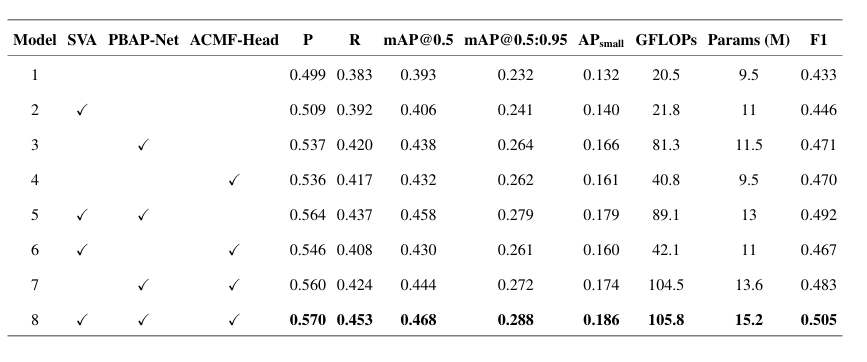

### **7.2. Lamaah vs. State-of-the-Art Methods on VisDrone2019**

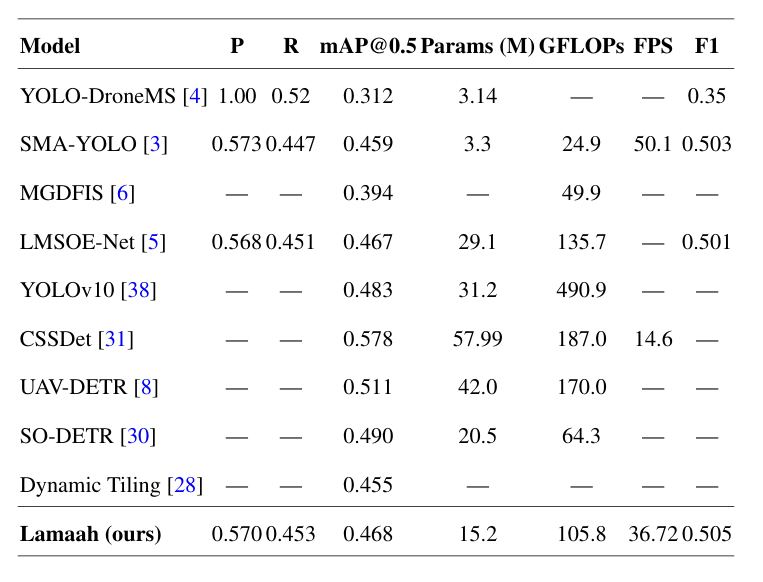

# **8. Conclusion and Future work**


---


* We proposed an improved YOLOv26-based framework for multi-scale object detection in UAV imagery.
* The model integrates SVA (better feature extraction), PBAP-Net (enhanced multi-scale fusion), and ACMF-head (adaptive feature refinement).

**Results on VisDrone2019 show:**
* 46.8% mAP@0.5 (+7.5% over baseline)
* 105.8 GFLOPs, 15.2M parameters (good accuracy-efficiency balance)

**Future work focuses on:**
* Real-time optimization for UAV deployment
* Improving model lightweightness and speed
* Testing on larger and more diverse datasets
* Exploring advanced methods (e.g., FullPAD, HyperACE)

# **💻 8. Interactive Demo**


---


This section presents an interactive demo of the proposed model, built using **HTML, CSS, and JavaScript** with a user-friendly interface.

* The model is deployed on **Hugging Face Spaces** using **Docker** for stable, real-time inference.
* Users can upload images and instantly view detection results with bounding boxes and confidence scores.

**Lamaah** is an AI-powered multi-scale object detection system optimized for complex scenes and varying object sizes.

* 🔗 **Try** [Lamaah](https://madaweealabdulkreem-lamaah-demo-app.hf.space/)

# **📖 9. References**
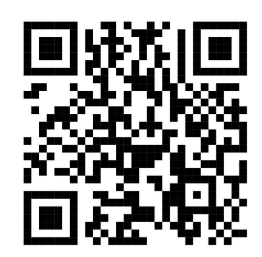